# LSN-0.4 — Deterministic, Probabilistic, Stochastic

| | |
|---|---|
| **Lesson** | `LSN-0.4` — Module `MOD-0` (Foundations), Week 1 |
| **Serves** | `OUT-0.2` — *explain deterministic vs probabilistic vs stochastic, and read "95% confident" as a claim about uncertainty, not a decoration* |
| **Duration** | 60 min session (25 + 20 + 15) + 20 min pre-work |
| **Verified by** | `ASM-0` — scenario questions, not definitions |
| **Homework** | **None** — checkpoint week. `ASM-0` opens instead. |
| **Lesson plan** | `program/lessons/LSN-0.4-deterministic-probabilistic-stochastic.md` |

**The instinct this session retires.** Senior engineers spend careers making systems deterministic, so
*"the same question gave a different answer"* reads as a defect. For a sampling system it is a **property** —
and a client who was never told that will file it as a P2 bug, correctly, because of what we implicitly
promised. Three words fix the conversation:

| Word | The one-line test | Anchor |
|---|---|---|
| **Deterministic** | same input → same output, **every** time | `2 + 2`, a SQL `SUM`, a build with pinned deps |
| **Probabilistic** | the output is a **guess with a stated confidence** | *"spam, confidence 0.87"* |
| **Stochastic** | there is **randomness inside the process** | retry jitter, load-balancer routing, SGD training, LLM sampling at temperature > 0 |

Those are the three buckets you will sort your own examples into in segment 1, and the three words you will
need in front of a client in segment 2.

**How to run this notebook.** Launch Jupyter from the repo root with the `LSN-0.1` venv active, then
`Run → Run All Cells`. It runs top to bottom, no arguments, no network, core stack only — and every number
below is computed from pinned seeds, so your output matches the projector's.

```
source .venv/bin/activate
jupyter notebook notebooks/lessons/LSN-0.4_Deterministic_Probabilistic_Stochastic.ipynb
```

**Order of business:**

1. **Pre-work — before the session** (~20 min): read the three keyword definitions below, then write **one
   example of each from your own project history** into the cell provided. Those examples are the raw
   material for segment 1 — a blank sheet is visible from the front of the room.
2. **Session** — three segments, in the lesson plan's order: the three-bucket sort, live (25 min) → why this
   matters commercially (20 min) → bridge to `MOD-1` (15 min).
3. **No homework.** `ASM-0` opens this week instead: async quiz, ~20 scenario questions, 30 min, pass bar
   **80%**, and it gates the start of `MOD-1`.

Fill-in cells never crash the notebook — they tell you what is still missing and wait for you.

> **Carried forward.** `LSN-0.2` asked *how many, and collected how?* · `LSN-0.3` added *conditional on
> what?* and audited a `0.87` spam score against 200,000 emails. Today asks the question that comes before
> both of them in a client meeting: **is this thing even supposed to give me the same answer twice?**

## Setup — imports, palette, and the seed trick

Three rules this notebook obeys, so your numbers and the projector's agree:

- **Everything is seeded.** Each demo builds its own generator from its own seed, so you can re-run any
  single cell in any order and get the same picture back.
- **Every chart uses the VSP palette**, drops its top/right spines, and labels its axes.
- **Core stack only** (`numpy`, `pandas`, `matplotlib` plus four stdlib modules). Nothing heavier is
  installed until Week 2, and nothing heavier is needed — the "model" in segment 1 is fifteen lines of numpy.

### The seed trick — and why it is itself part of the lesson

This lesson has an obvious problem: its subject is **output that varies between runs**, and its committed
output has to be **identical on every machine, forever**. Both, at once.

The resolution is the one production ML uses. One **parent seed** is pinned in the cell. From it we
`spawn()` a set of **child seeds**, and each child drives one simulated *"production run"*. So:

- across the eight runs *inside* a cell, the output **varies** — that is the stochastic behaviour, visible;
- across two executions of the *notebook*, every one of those eight runs is **bit-identical** — because the
  children are derived deterministically from the parent.

That is not a notebook trick. It is what a production ML system does when it pins seeds, model version and
temperature so that a bug report can be reproduced: **the randomness is real, and it is addressable.** Say
that sentence out loud in segment 2 and a client relaxes.

In [1]:
# numpy (arrays, distributions, seeded generators - the whole lesson)
import numpy as np
# pandas (the run tables and the bucket summaries)
import pandas as pd
# matplotlib (every chart in this notebook)
import matplotlib.pyplot as plt
# stdlib hashlib (sha256: the "looks random, is deterministic" demo in segment 1)
import hashlib
# stdlib math (comb: exact binomial probabilities for the acceptance-criterion arithmetic - no scipy here)
from math import comb
# stdlib json / getpass / datetime (the two artifacts this notebook saves to outputs/)
import json
import getpass
from datetime import datetime, timezone
# stdlib pathlib (locate the repo root without hardcoding a path)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for
# --- reference lines, bar edges and annotation text (VSP navy-darkest).
VSP = {
    "navy":   "#59709c",  # navy-light      - primary series
    "green":  "#65a74e",  # green           - second series
    "yellow": "#ffe86b",  # yellow          - highlight (always with a dark edge)
    "mint":   "#97f377",  # green-lightest  - third series
    "ink":    "#2b374d",  # navy-darkest    - lines, edges, text
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found - are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())

print(f"numpy {np.__version__} - pandas {pd.__version__}")
print(f"Repo root : {REPO_ROOT}")
print("[PASS] Setup complete - core stack only, palette loaded, paths resolved.")

numpy 2.5.1 - pandas 3.0.5
Repo root : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
[PASS] Setup complete - core stack only, palette loaded, paths resolved.


---

# Pre-work — do this **before** the session

*20 minutes total. No pre-work, no seat.*

| # | Task | Time | What to bring |
|---|---|---|---|
| 1 | Read the **keyword definitions** below — the keywords section of the ML literacy deck, restated here so the target is concrete (see the note at the end of this section) | 10 min | Nothing to submit — feeds task 2 |
| 2 | Write **one example of each term from your own project experience** — one line each — into the cell below | 10 min | **Three one-line examples**, submitted before the session. They are the raw material for segment 1 |

### The three keywords

**Deterministic.** Same input, same output, every time — and the same on your machine, mine, and in CI. The
output is a *function* of the input and nothing else. `2 + 2`. A SQL `SUM` over the same rows. A build with
pinned dependencies. A `sha256` digest. If you can cache the answer forever, it is deterministic.

**Probabilistic.** The output is a **guess with a stated confidence** — *"spam, confidence 0.87"*, *"73%
likely to close"*, *"95% confident"*. The number is not decoration and it is not a discount on the answer:
it is a claim about how often that guess is right, and it is **auditable**. Of the things this system scores
around 0.87, roughly 87 in 100 should turn out to be true. If they don't, the confidence is wrong even when
the answer is right.

**Stochastic.** There is **randomness inside the process itself**, so the same input can produce different
outputs on different runs. Retry jitter. Load-balancer routing. Shuffled mini-batches in training (SGD). An
LLM sampling its next word at temperature > 0. Note the difference from probabilistic: probabilistic is about
the *shape of the answer* (a guess with a confidence), stochastic is about the *machinery* (dice somewhere
inside). A system can be one, the other, both, or neither — and most real ML systems are different ones in
different places, which is the trap in segment 1.

Two more words from the same keyword set, so it is complete:

- **Confidence** — the auditable number attached to a probabilistic answer (`LSN-0.3`: a score is a bet you
  can check against what actually happened).
- **Inference** — running an already-trained model to get an answer, as opposed to **training**, which is how
  the model was built. Same system, three different buckets: **training** is stochastic, **inference** is
  deterministic once the weights are pinned, the **output** is probabilistic. Segment 1 ends by showing all
  three in one model.

> **Note on the source (a known materials gap).** The lesson plan's task 1 says *"re-read the keywords
> section of the ML literacy deck."* That deck is Tyler's and is **not in this repo yet** — its Materials row
> says "link at delivery prep". So the definitions above, and slide 2 of the `LSN-0.4` deck, carry the
> keyword content in the lesson plan's own framing and are the pre-work target until the deck lands. If you
> have the deck, read that section too; nothing here contradicts it.

In [2]:
# --- Pre-work task 2. Three examples from YOUR OWN project history, one line each.
#     Then run the cell. It never crashes, it never grades you, and it will not write your
#     examples for you - it tells you which line still needs work.
#
#     Aim for one concrete line each: the system, and what makes it that bucket.
#     Weak:   "our API"
#     Strong: "invoice totals endpoint - same invoice id returns the same cents every call, cached forever"

MY_DETERMINISTIC = ""   # something you built where the same input always gives the same output
MY_PROBABILISTIC = ""   # an output you have seen that was a guess with a confidence attached
MY_STOCHASTIC    = ""   # a process with randomness inside it

# Which of the three did you have to guess at? ("deterministic" / "probabilistic" / "stochastic")
# Whichever you name here is the column we sort first on the shared board - being unsure is useful.
LEAST_SURE_ABOUT = ""

# ---------------------------------------------------------------- checker (do not edit below)
MIN_CHARS = 40
_answers = {"MY_DETERMINISTIC": MY_DETERMINISTIC,
            "MY_PROBABILISTIC": MY_PROBABILISTIC,
            "MY_STOCHASTIC": MY_STOCHASTIC}
_prompts = {
    "MY_DETERMINISTIC": "same input -> same output, every time. A pure function, a SQL SUM over fixed "
                        "rows, a pinned build, a hash. Name the system AND the input/output pair.",
    "MY_PROBABILISTIC": "a guess WITH A NUMBER attached - a score, a percentage, a confidence, a "
                        "'likely'. If no number was ever shown to anyone, it is a weak example.",
    "MY_STOCHASTIC":    "randomness inside the machinery: jitter, shuffling, sampling, routing, a race, "
                        "a retry. Not 'the input data varies' - the PROCESS has dice in it.",
}
_buckets = ("deterministic", "probabilistic", "stochastic")

_short = [k for k, v in _answers.items() if len(v.strip()) < MIN_CHARS]
_bucket_ok = LEAST_SURE_ABOUT.strip().lower() in _buckets

# Advisory lint. These NEVER block the save - they are the misfiles segment 1 argues about, and
# arguing about them is the point. A flagged line is often the most interesting example in the room.
_advice = []
_det_smells = ("model", "predict", "forecast", "score", "llm", "gpt", "recommend", "classif")
if len(MY_DETERMINISTIC.strip()) >= MIN_CHARS and any(w in MY_DETERMINISTIC.lower() for w in _det_smells):
    _advice.append("MY_DETERMINISTIC mentions a model or a prediction. Trained models ARE deterministic "
                   "at inference with pinned weights - true, and worth defending out loud - but check "
                   "you have not filed a guess-with-a-confidence in the wrong column.")
_conf_words = ("%", "confidence", "probab", "score", "likel", "odds", "certain", "0.", "percent")
if len(MY_PROBABILISTIC.strip()) >= MIN_CHARS and not any(w in MY_PROBABILISTIC.lower() for w in _conf_words):
    _advice.append("MY_PROBABILISTIC has no number in it. What confidence did the output actually carry, "
                   "and who saw it? An answer with no stated confidence is just an answer.")
_rand_words = ("random", "jitter", "shuffl", "sampl", "retry", "race", "seed", "temperature", "route",
               "routing", "load balan", "timeout", "concurren", "monte", "bootstrap", "dropout", "sgd")
if len(MY_STOCHASTIC.strip()) >= MIN_CHARS and not any(w in MY_STOCHASTIC.lower() for w in _rand_words):
    _advice.append("MY_STOCHASTIC does not name where the randomness lives. Point at the dice: the "
                   "jitter, the shuffle, the sampler, the scheduler.")

if _short or not _bucket_ok:
    for _k in _short:
        print(f"[TODO] {_k}: needs a real one-liner ({MIN_CHARS}+ chars). {_prompts[_k]}")
    if not _bucket_ok:
        print('[TODO] LEAST_SURE_ABOUT: write one of "deterministic", "probabilistic", "stochastic".')
    print("\n       Nothing is saved until those are filled in. Twenty minutes, three lines, from your")
    print("       own project history - invented examples are obvious from the front of the room.")
else:
    submission = {
        "lesson": "LSN-0.4", "serves": ["OUT-0.2"], "assessment": "ASM-0",
        "artifact": "pre-work: three examples, one per bucket",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "deterministic": MY_DETERMINISTIC.strip(),
        "probabilistic": MY_PROBABILISTIC.strip(),
        "stochastic": MY_STOCHASTIC.strip(),
        "least_sure_about": LEAST_SURE_ABOUT.strip().lower(),
    }
    out_dir = REPO_ROOT / "outputs" / "lsn-0.4"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"prework_{getpass.getuser()}.json"
    out_path.write_text(json.dumps(submission, indent=2))
    print("[PASS] Three examples on file, one per bucket.")
    print(f"[SAVED] {out_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print(f"        Submit by referencing LSN-0.4. Least sure about: "
          f"{LEAST_SURE_ABOUT.strip().lower()} - we sort that column first.\n")
    if _advice:
        print("       [advisory only - your save is already done] two minutes of self-defence practice:")
        for _a in _advice:
            print(f"        - {_a}")
    else:
        print("       No flags. Bring them anyway - the interesting sort is always somebody's edge case.")

[TODO] MY_DETERMINISTIC: needs a real one-liner (40+ chars). same input -> same output, every time. A pure function, a SQL SUM over fixed rows, a pinned build, a hash. Name the system AND the input/output pair.
[TODO] MY_PROBABILISTIC: needs a real one-liner (40+ chars). a guess WITH A NUMBER attached - a score, a percentage, a confidence, a 'likely'. If no number was ever shown to anyone, it is a weak example.
[TODO] MY_STOCHASTIC: needs a real one-liner (40+ chars). randomness inside the machinery: jitter, shuffling, sampling, routing, a race, a retry. Not 'the input data varies' - the PROCESS has dice in it.
[TODO] LEAST_SURE_ABOUT: write one of "deterministic", "probabilistic", "stochastic".

       Nothing is saved until those are filled in. Twenty minutes, three lines, from your
       own project history - invented examples are obvious from the front of the room.


**Bring to the session:** those three lines, and a willingness to defend the one you were least sure about.
Segment 1 puts every participant's examples on a shared board with three columns and sorts them live —
including the ones that end up in a different column than the author intended. That is not a gotcha; the
misfiles are where the vocabulary actually gets installed.

---

# Segment 1 — The three-bucket sort *(25 min)*

**How the live sort runs.** Three columns on a shared board — **deterministic / probabilistic /
stochastic** — pre-seeded with the anchors from the table at the top of this notebook. Everyone's pre-work
examples go up. Sort them as a group, starting with the column the room was least sure about. Then the
instructor spends the last part of the segment on the **misfiled favourites** further down, because those are
the ones that transfer to a client conversation.

The cells that follow are the anchors, executed, so nobody has to take a definition on trust: one
deterministic thing checked across a thousand calls, one probabilistic thing audited against 200,000
outcomes, one stochastic pipeline run eight times — and one model that is all three at once.

## Bucket 1 — Deterministic: same input, same output, every time

The whole bucket in one sentence: **the output is a function of the input and nothing else.** No clock, no
machine identity, no dice, no state left over from the last call. If you can cache the answer forever, it is
deterministic.

Note what is *not* required: it does not have to be simple, fast, or predictable-*looking*. A `sha256` digest
looks like pure noise and is bone-deterministic — that one is on the misfile list on purpose.

In [3]:
# --- Bucket 1: DETERMINISTIC. Three anchors, checked rather than asserted rhetorically.

# Anchor 1: 2 + 2. Not a joke - it is the reference point the whole session leans on.
print(f"2 + 2 = {2 + 2}   (and it is 4 on every machine, in every run of this notebook, forever)\n")

# Anchor 2: a SQL SUM. Same rows in, same total out - here in pandas, but it is the same guarantee.
# Amounts are integer CENTS on purpose: money in cents is exact integer arithmetic. Sum the same
# numbers as FLOATS and the total can wobble in the last bits depending on the order they arrive -
# which is the misfile at the end of this segment, and the reason finance systems store cents.
invoices = pd.DataFrame({
    "client":       ["Meridian", "Meridian", "Halcyon", "Halcyon", "Halcyon", "Northwind"],
    "amount_cents": [1_845_000,      92_500,   310_000,   310_000,    47_250,   1_200_000],
})
totals = invoices.groupby("client")["amount_cents"].sum()
distinct_totals = {tuple(invoices.groupby("client")["amount_cents"].sum().items()) for _ in range(500)}
display(totals.to_frame("total_cents"))
print(f"[PASS] 500 runs of that GROUP BY produced {len(distinct_totals)} distinct answer.\n")

# Anchor 3: a hash. Looks random, is not. This is the most-misfiled example in the room.
payload = "invoice-4127|amount=18450.00|currency=CAD"
digests = {hashlib.sha256(payload.encode()).hexdigest() for _ in range(1_000)}
assert len(digests) == 1, "a hash that is not deterministic would be a broken hash"
digest = digests.pop()
print("[PASS] 1,000 sha256 calls on the same payload -> 1 distinct digest.")
print(f"       {digest}")

# ...and one character changed rewrites all of it. Sensitive, not random: every one of those
# characters is a fixed function of the input, and it is the SAME "noise" every single time.
nudged = hashlib.sha256(payload.replace("18450.00", "18450.01").encode()).hexdigest()
shared = sum(1 for a, b in zip(digest, nudged) if a == b)
print(f"       one cent more -> {nudged}")
print(f"       Those two digests share {shared} of 64 characters - which is what two unrelated hex")
print(f"       strings would share by luck ({64 // 16} positions in 64, one character in 16). Maximum")
print("       sensitivity to the input, zero randomness: same input, same digest, forever.")

2 + 2 = 4   (and it is 4 on every machine, in every run of this notebook, forever)



,total_cents
client,
Halcyon,667250
Meridian,1937500
Northwind,1200000


[PASS] 500 runs of that GROUP BY produced 1 distinct answer.

[PASS] 1,000 sha256 calls on the same payload -> 1 distinct digest.
       b2ec2d23ffc16261580233af161e090d851fc2a79aa9780c0725815900c02ce1
       one cent more -> 7a0f023e6e66244508fd3737467d3d40bca2c8fbb3582d96e4362e91a6fda2a3
       Those two digests share 4 of 64 characters - which is what two unrelated hex
       strings would share by luck (4 positions in 64, one character in 16). Maximum
       sensitivity to the input, zero randomness: same input, same digest, forever.


## Bucket 2 — Probabilistic: a guess with a confidence attached

`LSN-0.3` audited a `0.87` spam score against 200,000 emails and found that **87.4%** of the mail scored
between 0.85 and 0.89 really was spam. Same 200,000 emails below, same seed — because today's point is
different. Today there are **two** scorers:

- **Scorer A** is honest: it reports the belief it actually holds.
- **Scorer B** is **overconfident**: it takes A's belief and pushes it toward the extremes. Same hard
  predictions, same accuracy, more impressive-sounding numbers.

They are indistinguishable on the metric a client usually asks for. That is why `OUT-0.2` is worded the way
it is: **"95% confident" is a claim about uncertainty, not a decoration** — and it is a claim you can check.

In [4]:
# --- Bucket 2: PROBABILISTIC. Two scorers, one truth, 200,000 emails.
rng = np.random.default_rng(87)            # same seed as LSN-0.3, so the 0.87 band matches that session
N_EMAILS = 200_000

# Each email has some true chance of being spam. Beta(0.45, 0.45) is U-shaped: most mail is either
# obviously ham or obviously spam with a thin middle, which is what a real inbox looks like.
true_chance = rng.beta(0.45, 0.45, N_EMAILS)
is_spam = rng.random(N_EMAILS) < true_chance

score_A = true_chance                      # honest: reports the belief it actually holds
# Overconfident: the same belief pushed toward 0 and 1 on the log-odds scale. A monotone squash, so it
# never changes WHICH side of 0.5 an email lands on - only how loudly the model says it.
_p = np.clip(true_chance, 1e-12, 1 - 1e-12)
score_B = 1 / (1 + np.exp(-2.5 * np.log(_p / (1 - _p))))

# The two scorers make the SAME hard call on every single email...
same_calls = np.array_equal(score_A >= 0.5, score_B >= 0.5)
acc_A = ((score_A >= 0.5) == is_spam).mean()
acc_B = ((score_B >= 0.5) == is_spam).mean()
print(f"Identical spam/ham decisions on all {N_EMAILS:,} emails : {same_calls}")
print(f"Accuracy, scorer A                                  : {100 * acc_A:.2f}%")
print(f"Accuracy, scorer B                                  : {100 * acc_B:.2f}%"
      f"   <- the number a client asks for\n")

# ...and only one of them is telling the truth about how sure it is.
rows, gaps = [], {"A": [], "B": []}
for lo in np.arange(0.0, 1.0, 0.1):
    mid = lo + 0.05
    mA = (score_A >= lo) & (score_A < lo + 0.1)
    mB = (score_B >= lo) & (score_B < lo + 0.1)
    real_A, real_B = is_spam[mA].mean(), is_spam[mB].mean()
    gaps["A"].append(abs(mid - real_A))
    gaps["B"].append(abs(mid - real_B))
    rows.append({"model said": f"{lo:.1f} - {lo + 0.1:.1f}",
                 "A: emails": f"{mA.sum():,}", "A: really spam": f"{100 * real_A:.1f}%",
                 "B: emails": f"{mB.sum():,}", "B: really spam": f"{100 * real_B:.1f}%"})
display(pd.DataFrame(rows).set_index("model said"))

in_band = lambda s, lo, hi: (s >= lo) & (s < hi)
nA, nB = in_band(score_A, 0.93, 0.97), in_band(score_B, 0.93, 0.97)
print(f'Said "0.95" -- scorer A: {nA.sum():,} emails, {100 * is_spam[nA].mean():.1f}% really were spam.')
print(f'Said "0.95" -- scorer B: {nB.sum():,} emails, {100 * is_spam[nB].mean():.1f}% really were spam.')
print("\nMean gap between what was said and what happened, across the ten bands:")
print(f"  scorer A : {100 * np.mean(gaps['A']):.1f} points"
      f"   <- calibrated: the confidence is a fact about the world")
print(f"  scorer B : {100 * np.mean(gaps['B']):.1f} points"
      f"   <- theatre: same answers, inflated confidence")
nar = in_band(score_A, 0.85, 0.89)
print(f"\n(LSN-0.3 callback: scorer A's 0.85-0.89 band is {nar.sum():,} emails, "
      f"{100 * is_spam[nar].mean():.1f}% spam - the same number as last session.)")

Identical spam/ham decisions on all 200,000 emails : True
Accuracy, scorer A                                  : 82.89%
Accuracy, scorer B                                  : 82.89%   <- the number a client asks for



,A: emails,A: really spam,B: emails,B: really spam
model said,,,,
0.0 - 0.1,"44,334",3.2%,"74,768",9.8%
0.1 - 0.2,"17,312",15.0%,"9,146",32.5%
0.2 - 0.3,"14,010",25.6%,"6,112",39.7%
0.3 - 0.4,"12,525",34.7%,"5,224",43.4%
0.4 - 0.5,"11,814",45.0%,"4,745",47.7%
0.5 - 0.6,"11,689",55.2%,"4,705",51.7%
0.6 - 0.7,"12,580",64.9%,"5,092",57.6%
0.7 - 0.8,"14,083",75.3%,"6,237",60.0%
0.8 - 0.9,"17,477",85.7%,"9,092",67.4%


Said "0.95" -- scorer A: 11,992 emails, 95.3% really were spam.
Said "0.95" -- scorer B: 9,032 emails, 76.9% really were spam.

Mean gap between what was said and what happened, across the ten bands:
  scorer A : 0.6 points   <- calibrated: the confidence is a fact about the world
  scorer B : 9.6 points   <- theatre: same answers, inflated confidence

(LSN-0.3 callback: scorer A's 0.85-0.89 band is 7,552 emails, 87.4% spam - the same number as last session.)


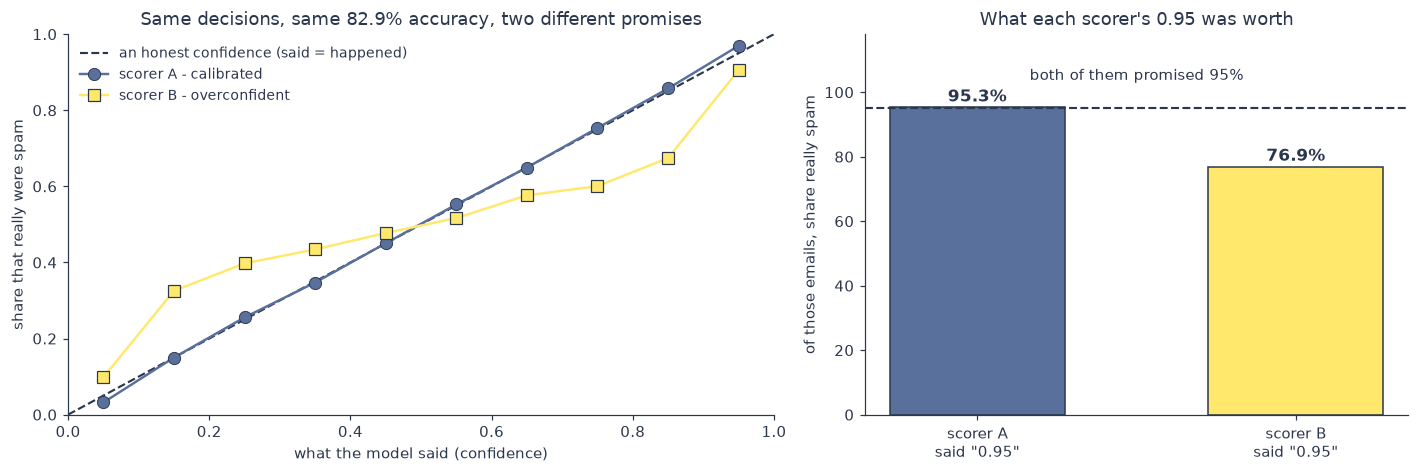

In [5]:
# --- Figure: a confidence is a promise you can audit - and two scorers with identical accuracy
# --- can differ completely on whether they keep it.
fig, (ax_cal, ax_band) = plt.subplots(1, 2, figsize=(13.0, 4.4),
                                      gridspec_kw={"width_ratios": [1.3, 1]})

centres = np.arange(0.05, 1.0, 0.1)
obs_A = [is_spam[(score_A >= c - 0.05) & (score_A < c + 0.05)].mean() for c in centres]
obs_B = [is_spam[(score_B >= c - 0.05) & (score_B < c + 0.05)].mean() for c in centres]
ax_cal.plot([0, 1], [0, 1], color=VSP["ink"], linestyle="--", linewidth=1.4,
            label="an honest confidence (said = happened)")
ax_cal.plot(centres, obs_A, marker="o", markersize=8, color=VSP["navy"], linewidth=1.6,
            markeredgecolor=VSP["ink"], markeredgewidth=0.6, label="scorer A - calibrated")
ax_cal.plot(centres, obs_B, marker="s", markersize=8, color=VSP["yellow"], linewidth=1.6,
            markeredgecolor=VSP["ink"], markeredgewidth=0.8, label="scorer B - overconfident")
ax_cal.set_xlabel("what the model said (confidence)")
ax_cal.set_ylabel("share that really were spam")
ax_cal.set_title(f"Same decisions, same {100 * acc_A:.1f}% accuracy, two different promises")
ax_cal.set_xlim(0, 1)
ax_cal.set_ylim(0, 1)
ax_cal.legend(loc="upper left", fontsize=9)
ax_cal.spines[["top", "right"]].set_visible(False)

heights = [100 * is_spam[nA].mean(), 100 * is_spam[nB].mean()]
bars = ax_band.bar(['scorer A\nsaid "0.95"', 'scorer B\nsaid "0.95"'], heights,
                   color=[VSP["navy"], VSP["yellow"]], edgecolor=VSP["ink"], linewidth=1.0, width=0.55)
ax_band.axhline(95, color=VSP["ink"], linestyle="--", linewidth=1.4)
ax_band.text(0.5, 105, "both of them promised 95%", va="center", ha="center", fontsize=9.5,
             color=VSP["ink"])
for b, h in zip(bars, heights):
    ax_band.text(b.get_x() + b.get_width() / 2, h + 1.8, f"{h:.1f}%", ha="center", fontsize=11,
                 fontweight="bold", color=VSP["ink"])
ax_band.set_ylim(0, 118)
ax_band.set_ylabel("of those emails, share really spam")
ax_band.set_title("What each scorer's 0.95 was worth")
ax_band.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### `OUT-0.2`, landed: three ways to read "95% confident"

| Reading | Verdict |
|---|---|
| *"The system is 95% accurate."* | **Wrong.** Different claim, different number. Scorer B is 82.9% accurate and says 0.95 all day. |
| *"It's mostly sure — treat it as a yes."* | **Decoration.** The number has been thrown away; you now hold a verdict you cannot audit. |
| *"Of the cases it calls 0.95, about 95 in 100 should be right — and we check."* | **The only legitimate reading.** A testable claim about the future, and a vendor should be able to show you the table above. |

Ask for that table. *"When your model says 0.9, how often is it right?"* is the single most useful question in
this session: five minutes' work for a vendor who has ever looked, and the silence from one who hasn't is
diagnostic. `LSN-1.2` reads a lead score of `0.73` exactly this way; `LSN-1.3` names the metrics.

## Bucket 3 — Stochastic: the same pipeline, run eight times

The demo below is a **toy sampler** in a dozen lines of numpy, standing in for the generation step of the
in-production **meeting-RAG** system — the one segment 2 is about. A user asks:

> *"What did we commit to on the Meridian integration?"*

Retrieval has already done its job, and five candidate phrasings of the **same answer** come back with
scores attached. Read the five carefully: **the facts are identical in every one** — read-only sync, end of
Q2, agreed March 14, same citation. Only the wording differs. Hold on to that; it is the whole of segment 2.

Then the pipeline picks one, and *how* it picks is a knob called **temperature**:

- **temperature 0** → always take the top-scoring candidate (*greedy*). The dice are never rolled.
- **temperature 1** → sample in proportion to the scores. The top candidate is still the most likely; it is
  just no longer the only possibility.
- **higher temperature** → flatter odds, more variety, more risk.

`MOD-2` (`LSN-2.1`) does what is really happening inside an LLM, token by token. Today it is one choice out
of five, in pure numpy, so the *mechanism* is visible.

In [6]:
# --- Bucket 3: STOCHASTIC. One pipeline, eight runs, with the seed trick made explicit.
#
# THE SEED TRICK (it is on the slide too, and it is itself a teachable point):
#   In production nobody controls the randomness - every request is a fresh roll of the dice.
#   A committed notebook has to print the same thing forever. We need BOTH.
#   So: one PARENT seed, pinned here, spawned into eight CHILD seeds. Each child = one production run.
#   Variation ACROSS the eight runs is real. Variation across two executions of this cell is zero,
#   because the children are derived deterministically from the parent. That is exactly what a
#   production ML system does when it pins seed + model version + temperature so a bug can be replayed.
parent = np.random.SeedSequence(404)         # pinned: the notebook must print the same thing forever
run_seeds = parent.spawn(8)                  # eight "production runs", each with its own child seed

CANDIDATES = [
    "A: The March 14 call: read-only Meridian sync, ship by end of Q2.  [03-14 @ 41:12]",
    "B: On March 14 you agreed to a read-only Meridian sync, targeted end of Q2.  [03-14 @ 41:12]",
    "C: Commitment: a read-only sync with Meridian, end of Q2.  [03-14 @ 41:12]",
    "D: Meridian: read-only sync, Q2. Agreed on the March 14 call.  [03-14 @ 41:12]",
    "E: You settled on a read-only Meridian sync for Q2, on March 14.  [03-14 @ 41:12]",
]
SCORES = np.array([2.6, 2.4, 1.9, 1.1, 0.4])     # the model's preference for each phrasing
LABELS = ["A", "B", "C", "D", "E"]


def softmax(scores, temperature):
    """Turn scores into probabilities. Lower temperature -> sharper, higher -> flatter."""
    z = scores / temperature
    z = z - z.max()                  # numerically safe shift; does not change the result
    e = np.exp(z)
    return e / e.sum()


def answer_once(rng, temperature):
    """One generation. temperature=0 is greedy: the rng is never consulted."""
    if temperature == 0:
        return int(np.argmax(SCORES))
    return int(rng.choice(len(SCORES), p=softmax(SCORES, temperature)))


runs = []
for i, seed in enumerate(run_seeds, start=1):
    at_0 = answer_once(np.random.default_rng(seed), temperature=0)
    at_1 = answer_once(np.random.default_rng(seed), temperature=1.0)
    runs.append({"run": f"#{i}", "child seed": str(seed.spawn_key),
                 "temperature 0": LABELS[at_0], "temperature 1": LABELS[at_1]})
runs_df = pd.DataFrame(runs).set_index("run")
display(runs_df)

picks_t0 = runs_df["temperature 0"].tolist()
picks_t1 = runs_df["temperature 1"].tolist()
print(f"Distinct answers over 8 runs at temperature 0 : {len(set(picks_t0))}   ({''.join(picks_t0)})")
print(f"Distinct answers over 8 runs at temperature 1 : {len(set(picks_t1))}   ({''.join(picks_t1)})")

p1 = softmax(SCORES, 1.0)
agree = float((p1 ** 2).sum())
print(f"\nP(two independent runs return the SAME phrasing) at temperature 1 : {100 * agree:.1f}%")
print(f"So a user who asks the same question twice sees different wording  : {100 * (1 - agree):.1f}% of the time.")
print("That is the support ticket in segment 2 - and nothing is broken.\n")
print("Runs #1 and #2 in full: the two answers a client pastes into a bug report.")
print(f"  run #1 : {CANDIDATES[LABELS.index(picks_t1[0])]}")
print(f"  run #2 : {CANDIDATES[LABELS.index(picks_t1[1])]}")

# Stability WITHIN a pinned seed: the same child seed, replayed, gives the same sequence of draws.
_r1 = np.random.default_rng(run_seeds[0])
_r2 = np.random.default_rng(run_seeds[0])
seq_1 = "".join(LABELS[answer_once(_r1, 1.0)] for _ in range(6))
seq_2 = "".join(LABELS[answer_once(_r2, 1.0)] for _ in range(6))
assert seq_1 == seq_2, "a pinned seed must reproduce its own sequence"
print(f"\n[PASS] Pinned seed, replayed: {seq_1} == {seq_2}")
print("       Stochastic does not mean unreproducible. It means the randomness is real - and addressable.")

,child seed,temperature 0,temperature 1
run,,,
#1,"(0,)",A,A
#2,"(1,)",A,B
#3,"(2,)",A,C
#4,"(3,)",A,A
#5,"(4,)",A,B
#6,"(5,)",A,B
#7,"(6,)",A,A
#8,"(7,)",A,A


Distinct answers over 8 runs at temperature 0 : 1   (AAAAAAAA)
Distinct answers over 8 runs at temperature 1 : 3   (ABCABBAA)

P(two independent runs return the SAME phrasing) at temperature 1 : 28.2%
So a user who asks the same question twice sees different wording  : 71.8% of the time.
That is the support ticket in segment 2 - and nothing is broken.

Runs #1 and #2 in full: the two answers a client pastes into a bug report.
  run #1 : A: The March 14 call: read-only Meridian sync, ship by end of Q2.  [03-14 @ 41:12]
  run #2 : B: On March 14 you agreed to a read-only Meridian sync, targeted end of Q2.  [03-14 @ 41:12]

[PASS] Pinned seed, replayed: AEABCA == AEABCA
       Stochastic does not mean unreproducible. It means the randomness is real - and addressable.


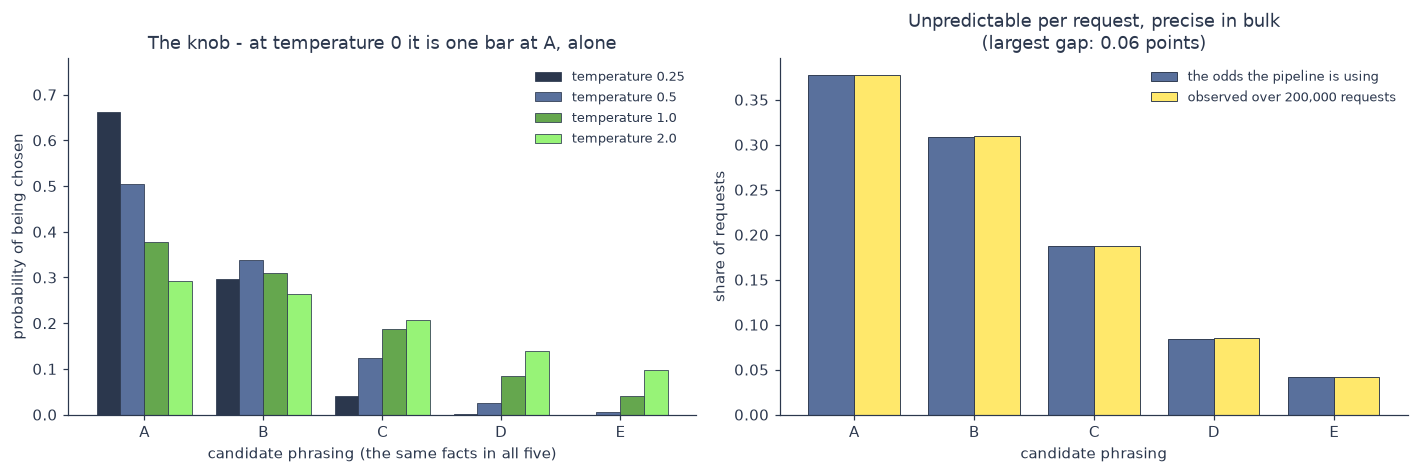

Left : turn the knob down and the odds sharpen; turn it up and rare phrasings get their turn.
Right: you cannot predict one answer, and you can predict ten thousand of them precisely.
       That is what makes a service-level number on a stochastic system possible - segment 2.


In [7]:
# --- Figure: the temperature knob, and what "sampling in proportion to the scores" really means.
fig, (ax_temp, ax_freq) = plt.subplots(1, 2, figsize=(13.0, 4.4))

temps = [0.25, 0.5, 1.0, 2.0]
colours = [VSP["ink"], VSP["navy"], VSP["green"], VSP["mint"]]
x = np.arange(len(LABELS))
width = 0.2
for k, (T, colour) in enumerate(zip(temps, colours)):
    ax_temp.bar(x + (k - 1.5) * width, softmax(SCORES, T), width=width, color=colour,
                edgecolor=VSP["ink"], linewidth=0.5, label=f"temperature {T}")
ax_temp.set_xticks(x)
ax_temp.set_xticklabels(LABELS)
ax_temp.set_xlabel("candidate phrasing (the same facts in all five)")
ax_temp.set_ylabel("probability of being chosen")
ax_temp.set_title("The knob - at temperature 0 it is one bar at A, alone")
ax_temp.set_ylim(0, 0.78)
ax_temp.legend(fontsize=8.5, loc="upper right")
ax_temp.spines[["top", "right"]].set_visible(False)

# Long run: 200,000 requests at temperature 1, driven by a ninth child of the same parent.
long_run_seed = np.random.SeedSequence(404).spawn(9)[8]
draws = np.random.default_rng(long_run_seed).choice(len(SCORES), size=200_000, p=softmax(SCORES, 1.0))
freq = np.bincount(draws, minlength=len(SCORES)) / len(draws)
ax_freq.bar(x - 0.19, softmax(SCORES, 1.0), width=0.38, color=VSP["navy"], edgecolor=VSP["ink"],
            linewidth=0.6, label="the odds the pipeline is using")
ax_freq.bar(x + 0.19, freq, width=0.38, color=VSP["yellow"], edgecolor=VSP["ink"],
            linewidth=0.6, label="observed over 200,000 requests")
ax_freq.set_xticks(x)
ax_freq.set_xticklabels(LABELS)
ax_freq.set_xlabel("candidate phrasing")
ax_freq.set_ylabel("share of requests")
ax_freq.set_title("Unpredictable per request, precise in bulk\n"
                  f"(largest gap: {100 * np.max(np.abs(freq - softmax(SCORES, 1.0))):.2f} points)")
ax_freq.legend(fontsize=8.5)
ax_freq.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Left : turn the knob down and the odds sharpen; turn it up and rare phrasings get their turn.")
print("Right: you cannot predict one answer, and you can predict ten thousand of them precisely.")
print("       That is what makes a service-level number on a stochastic system possible - segment 2.")

## The misfiled favourites *(the part that transfers)*

Every room files these three wrong, and every one of them shows up in a client conversation.

| The example | The instinct | What it actually is |
|---|---|---|
| **A flaky test** | "the test is stochastic" | **Deterministic code in a stochastic environment.** The code is a function of its inputs — but the *inputs* include a clock, a port, a thread schedule, a DNS response. Nothing in the test is sampling; you are missing an input. |
| **A hash function** | "the output looks random" | **Deterministic**, and violently so — 1,000 calls, one digest, and one changed character rewrites the whole thing. *Looks random* and *is random* are unrelated properties. |
| **An LLM at temperature 0** | "so it's deterministic" | **Near-deterministic in practice, not contractually.** Greedy decoding never rolls the dice — but floating-point addition is not associative, so batching, hardware and kernel changes move the last bits of a score. When the top two candidates are that close, the winner flips. The cell below does it. |

*Delivery note from the lesson plan: cap the temperature-0 debate at **two minutes** and park the rest for
`LSN-2.1`. The cell exists so that the answer can be a demonstration instead of an argument.*

In [8]:
# --- Why "temperature 0" is not a contract. Two minutes, then move on.
print(f"0.1 + 0.2 == 0.3 ?  {0.1 + 0.2 == 0.3}      (it is {0.1 + 0.2!r})")
print("Floating-point addition is not associative: the ORDER you add numbers in changes the answer.\n")

r = np.random.default_rng(2026)
contributions = r.normal(0, 1, 24) * 1e3     # the 24 numbers that add up to one candidate's score


def add_up(values):
    """Sum in exactly the order given - one accumulator, no pairwise tricks."""
    total = 0.0
    for v in values:
        total += v
    return total


served_alone   = add_up(contributions)               # this request served on its own
served_batched = add_up(contributions[::-1])         # the SAME numbers, a different reduction order

print(f"one candidate's score, request served alone   : {served_alone!r}")
print(f"the same score, request served in a batch     : {served_batched!r}")
print(f"gap                                          : {served_batched - served_alone:.3e}"
      f"   ({abs(served_batched - served_alone) / abs(served_alone):.1e} relative)\n")

# Now two candidate phrasings whose scores are EXACTLY EQUAL in exact arithmetic - the same numbers,
# added in different orders. Greedy decoding still has to pick one, and it picks on the last bits.
scored_the_same_way = np.array([served_alone, served_alone])
one_of_them_batched = np.array([served_alone, served_batched])
print(f"greedy pick, both candidates scored identically   : candidate {int(np.argmax(scored_the_same_way)) + 1}")
print(f"greedy pick, candidate 2 scored inside a batch    : candidate {int(np.argmax(one_of_them_batched)) + 1}")
print("\nSame model, same prompt, temperature 0, two mathematically tied candidates - and the winner")
print("depends on what else happened to be in the batch. One word changes; the sentence changes.")
print("[LANDING] Temperature 0 buys you 'almost always the same answer'. It does not buy you a")
print("          contractual guarantee, and you should not write one into a statement of work.")

0.1 + 0.2 == 0.3 ?  False      (it is 0.30000000000000004)
Floating-point addition is not associative: the ORDER you add numbers in changes the answer.



one candidate's score, request served alone   : np.float64(-2138.5469939971995)
the same score, request served in a batch     : np.float64(-2138.546993997199)
gap                                          : 4.547e-13   (2.1e-16 relative)

greedy pick, both candidates scored identically   : candidate 1
greedy pick, candidate 2 scored inside a batch    : candidate 2

Same model, same prompt, temperature 0, two mathematically tied candidates - and the winner
depends on what else happened to be in the batch. One word changes; the sentence changes.
[LANDING] Temperature 0 buys you 'almost always the same answer'. It does not buy you a
          contractual guarantee, and you should not write one into a statement of work.


## One system, all three buckets — the synthesis

The sort is not a property of *systems*, it is a property of *the thing you are pointing at*. Below is a
lead-scoring model — fifteen lines of numpy, two features, trained by mini-batch gradient descent, which is
the **SGD** anchor from the stochastic column. (`MOD-1` is where you learn what training is. This cell only
asks you to accept that it involves a random starting point, a random shuffle, and this week's sample of the
data.)

Watch which numbers move:

- **Training is stochastic** — eight retrains of the same code on the same pool give eight different models.
- **Inference is deterministic** — pin the weights and one deal's score is the same forever.
- **The output is probabilistic** — a guess with a confidence, where the confidence *is* the answer.

In [9]:
# --- One system, three buckets. A toy lead-scorer: 2 features, logistic output, trained by SGD.
data_rng = np.random.default_rng(1127)        # the DATA is fixed - only the training is stochastic
N_DEALS = 6_000
touches = data_rng.normal(0, 1, N_DEALS)                              # engagement, standardised
days    = data_rng.normal(0, 1, N_DEALS)                              # days since contact, standardised
p_close = 1 / (1 + np.exp(-(1.15 * touches - 0.85 * days - 0.25)))     # the world's true odds
closed  = data_rng.random(N_DEALS) < p_close

X, y = np.column_stack([touches, days]), closed.astype(float)
POOL = 2_000                                    # the training pool
X_pool, y_pool = X[:POOL], y[:POOL]
X_test, y_test = X[4_000:], closed[4_000:]      # a held-out slice, identical for every retrain
DEAL_5820 = np.array([0.55, -0.10])             # one deal sitting in this week's pipeline review


def train(seed, epochs=4, batch=32, lr=0.2):
    """Mini-batch gradient descent. Three sources of randomness, all real, all normal practice:
    this week's sample of the pool, the starting weights, and the shuffle order each epoch."""
    r = np.random.default_rng(seed)
    idx = r.integers(0, POOL, POOL)                        # this retrain's sample of the data
    X_t, y_t = X_pool[idx], y_pool[idx]
    w, b = r.normal(0, 0.5, 2), float(r.normal(0, 0.5))    # random starting point
    for _ in range(epochs):
        for j in np.array_split(r.permutation(POOL), POOL // batch):   # a fresh shuffle each epoch
            p = 1 / (1 + np.exp(-(X_t[j] @ w + b)))
            w -= lr * (X_t[j].T @ (p - y_t[j])) / len(j)
            b -= lr * float((p - y_t[j]).mean())
    return w, b


def score_deal(model, x):
    w, b = model
    return float(1 / (1 + np.exp(-(x @ w + b))))


retrain_seeds = np.random.SeedSequence(5820).spawn(8)       # eight retrains = eight child seeds
models = [train(s) for s in retrain_seeds]
accs = [float((((X_test @ w + b) >= 0) == y_test).mean()) for w, b in models]
scores_5820 = [score_deal(m, DEAL_5820) for m in models]
display(pd.DataFrame([{"retrain": f"#{i}",
                       "weight: touches": f"{w[0]:+.2f}", "weight: days": f"{w[1]:+.2f}",
                       "bias": f"{b:+.2f}",
                       "score for deal #5820": f"{scores_5820[i - 1]:.3f}",
                       "accuracy on the same test set": f"{100 * accs[i - 1]:.1f}%"}
                      for i, (w, b) in enumerate(models, start=1)]).set_index("retrain"))

print(f"STOCHASTIC training     : 8 retrains, 8 different models. Accuracy moves "
      f"{100 * (max(accs) - min(accs)):.1f} points "
      f"({100 * min(accs):.1f}% - {100 * max(accs):.1f}%) ...")
print(f"                          ... and deal #5820's score moves "
      f"{100 * (max(scores_5820) - min(scores_5820)):.1f} points "
      f"({min(scores_5820):.2f} - {max(scores_5820):.2f}).")
print("                          The client sees the score, not the accuracy.")

pinned = models[0]
assert len({score_deal(pinned, DEAL_5820) for _ in range(1_000)}) == 1
print(f"DETERMINISTIC inference : weights pinned -> 1,000 calls, 1 distinct answer "
      f"({score_deal(pinned, DEAL_5820):.6f}).")
print(f"PROBABILISTIC output    : that {score_deal(pinned, DEAL_5820):.2f} is a guess with a confidence. "
      f"LSN-1.2 reads one of these\n                          for a client; LSN-1.3 grades it.")

,weight: touches,weight: days,bias,score for deal #5820,accuracy on the same test set
retrain,,,,,
#1,+1.22,-0.76,-0.11,0.654,73.4%
#2,+1.23,-0.68,-0.21,0.631,73.2%
#3,+1.20,-0.72,-0.23,0.624,73.5%
#4,+1.16,-0.69,-0.16,0.633,73.6%
#5,+1.18,-0.65,-0.16,0.634,73.2%
#6,+1.22,-0.63,-0.24,0.622,72.8%
#7,+1.18,-0.75,-0.10,0.651,73.2%
#8,+1.15,-0.66,-0.26,0.608,73.2%


STOCHASTIC training     : 8 retrains, 8 different models. Accuracy moves 0.8 points (72.8% - 73.6%) ...
                          ... and deal #5820's score moves 4.5 points (0.61 - 0.65).
                          The client sees the score, not the accuracy.
DETERMINISTIC inference : weights pinned -> 1,000 calls, 1 distinct answer (0.653743).
PROBABILISTIC output    : that 0.65 is a guess with a confidence. LSN-1.2 reads one of these
                          for a client; LSN-1.3 grades it.


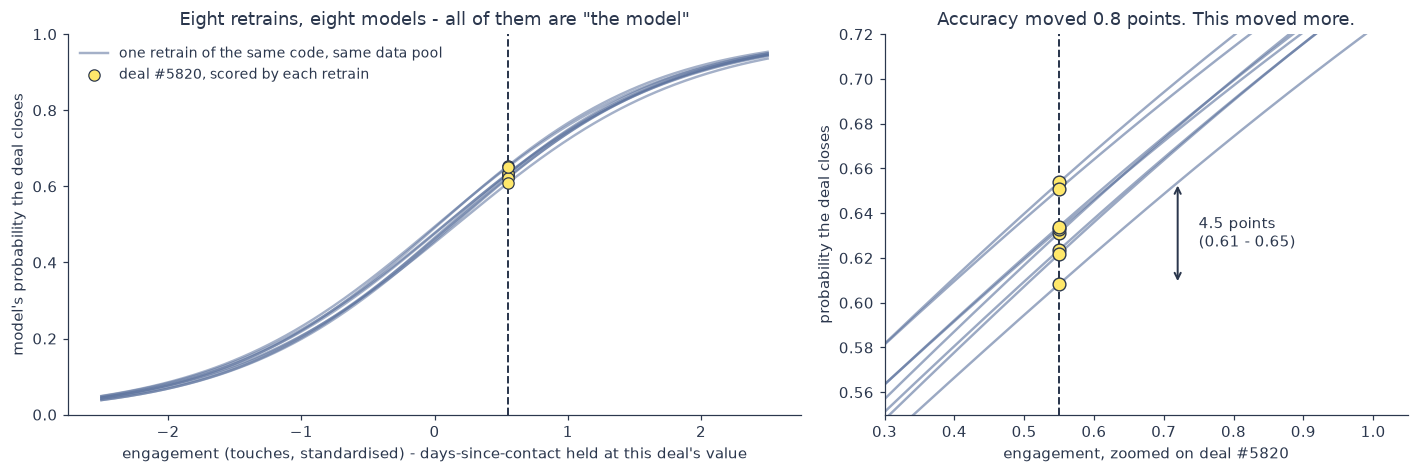

Nobody in this picture has a bug. But if the client's dashboard shows that score to two decimals
and somebody retrains on Tuesday, the second decimal is noise you have published as a fact.
That is a design decision, and it gets made before the demo - which is segment 2.


In [10]:
# --- Figure: eight retrains of the same code, and the one deal sitting inside the fan.
fig, (ax_all, ax_zoom) = plt.subplots(1, 2, figsize=(13.0, 4.4),
                                      gridspec_kw={"width_ratios": [1.4, 1]})
grid = np.linspace(-2.5, 2.5, 300)
for i, (w, b) in enumerate(models):
    curve = 1 / (1 + np.exp(-(w[0] * grid + w[1] * DEAL_5820[1] + b)))
    ax_all.plot(grid, curve, color=VSP["navy"], alpha=0.55, linewidth=1.6,
                label="one retrain of the same code, same data pool" if i == 0 else None)
    ax_zoom.plot(grid, curve, color=VSP["navy"], alpha=0.6, linewidth=1.6)
ax_all.axvline(DEAL_5820[0], color=VSP["ink"], linestyle="--", linewidth=1.3)
ax_all.scatter([DEAL_5820[0]] * len(scores_5820), scores_5820, s=55, color=VSP["yellow"],
               edgecolor=VSP["ink"], linewidth=0.8, zorder=3, label="deal #5820, scored by each retrain")
ax_all.set_xlabel("engagement (touches, standardised) - days-since-contact held at this deal's value")
ax_all.set_ylabel("model's probability the deal closes")
ax_all.set_title("Eight retrains, eight models - all of them are \"the model\"")
ax_all.set_ylim(0, 1)
ax_all.legend(loc="upper left", fontsize=9)
ax_all.spines[["top", "right"]].set_visible(False)

# Right: the same picture, zoomed to the one deal - the spread the client's dashboard shows.
ax_zoom.axvline(DEAL_5820[0], color=VSP["ink"], linestyle="--", linewidth=1.3)
ax_zoom.scatter([DEAL_5820[0]] * len(scores_5820), scores_5820, s=70, color=VSP["yellow"],
                edgecolor=VSP["ink"], linewidth=0.9, zorder=3)
ax_zoom.annotate("", xy=(0.72, min(scores_5820)), xytext=(0.72, max(scores_5820)),
                 arrowprops=dict(arrowstyle="<->", color=VSP["ink"], linewidth=1.3))
ax_zoom.text(0.75, (min(scores_5820) + max(scores_5820)) / 2,
             f"{100 * (max(scores_5820) - min(scores_5820)):.1f} points\n"
             f"({min(scores_5820):.2f} - {max(scores_5820):.2f})",
             va="center", ha="left", fontsize=10, color=VSP["ink"])
ax_zoom.set_xlim(0.30, 1.05)
ax_zoom.set_ylim(0.55, 0.72)
ax_zoom.set_xlabel("engagement, zoomed on deal #5820")
ax_zoom.set_ylabel("probability the deal closes")
ax_zoom.set_title(f"Accuracy moved {100 * (max(accs) - min(accs)):.1f} points. This moved more.")
ax_zoom.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Nobody in this picture has a bug. But if the client's dashboard shows that score to two decimals")
print("and somebody retrains on Tuesday, the second decimal is noise you have published as a fact.")
print("That is a design decision, and it gets made before the demo - which is segment 2.")

### The sort, as a table you can use in a meeting

| Point at… | Deterministic | Probabilistic | Stochastic |
|---|---|---|---|
| `2 + 2`, a SQL `SUM` over fixed rows, a pinned build, a `sha256` | ✅ | — | — |
| A trained model's **output** ("0.87 spam", "0.65 to close") | — | ✅ | — |
| That model's **inference call**, weights pinned | ✅ | — | — |
| That model's **training run** (random init, shuffled batches, this week's sample) | — | — | ✅ |
| An LLM sampling at **temperature > 0** | — | — | ✅ |
| An LLM at **temperature 0** | *almost* — not contractually | — | — |
| A flaky test | ✅ (the code) | — | ✅ (the environment) |
| Retry jitter, load-balancer routing | — | — | ✅ |

**The move that makes you sound senior:** never answer *"is your system deterministic?"* with yes or no. Ask
**"which part?"** — then answer per part, in this vocabulary. That is the whole of `OUT-0.2`.

## The second axis — *would more data fix this?*

The three buckets tell you **what kind** of uncertainty you are looking at. Clients ask a different
question, and it is the one attached to a budget:

> ### "If we give you more data, will it get better?"

There are only two answers, and they have names.

- **Irreducible** — variation in the process itself. Two identical jobs really do take different amounts of
  time; two identical leads really do convert differently. More data does not remove it, because there is
  nothing there to learn. This is the **stochastic** bucket, seen from the client's side.
- **Reducible** — the model has not seen enough, or is the wrong shape. More and better data shrinks it, and
  you can say roughly by how much.

Every real error is a mix. The cell below separates them on a system where we *know* the true rule, so we
can measure the floor instead of guessing at it.

In [11]:
# --- The second axis: reducible vs irreducible, measured.
# --- A rule with 8 inputs, plus process noise we control. Because we WROTE the true rule, we can
# --- compute the error a perfect model would still make - the floor nothing can go below.
rng = np.random.default_rng(2109)
D, NOISE_SD, POOL = 8, 6.0, 30_000

TRUE_WEIGHTS = np.array([2.4, -1.7, 0.9, 3.1, -2.2, 1.4, -0.6, 2.0])
TRUE_OFFSET = 15.0

X = rng.normal(0, 1, (POOL, D))
Y = X @ TRUE_WEIGHTS + TRUE_OFFSET + rng.normal(0, NOISE_SD, POOL)

X_test, Y_test = X[:5_000], Y[:5_000]                      # held out, never trained on
A_test = np.hstack([X_test, np.ones((len(X_test), 1))])

# The floor: how wrong a PERFECT model still is, because the process itself varies.
IRREDUCIBLE = np.abs(Y_test - (X_test @ TRUE_WEIGHTS + TRUE_OFFSET)).mean()

rows = []
for n in (10, 20, 40, 80, 200, 500, 2_000, 10_000):
    xs, ys = X[5_000:5_000 + n], Y[5_000:5_000 + n]
    A = np.hstack([xs, np.ones((n, 1))])
    coefficients, *_ = np.linalg.lstsq(A, ys, rcond=None)   # plain least squares - no sklearn (SI-1)
    mae = np.abs(A_test @ coefficients - Y_test).mean()
    rows.append({"training rows": n,
                 "average miss": round(mae, 2),
                 "reducible part left": round(mae - IRREDUCIBLE, 2)})

print(f"Irreducible floor - the miss a PERFECT model still makes : {IRREDUCIBLE:.2f}\n")
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nFrom 10 rows to 10,000 rows, the average miss falls "
      f"{rows[0]['average miss']:.2f} -> {rows[-1]['average miss']:.2f}.")
print(f"Everything above {IRREDUCIBLE:.2f} was reducible and got bought with data.")
print(f"The {IRREDUCIBLE:.2f} that remains is the process. No amount of data touches it.")

Irreducible floor - the miss a PERFECT model still makes : 4.83

 training rows  average miss  reducible part left
            10         34.86                30.03
            20          6.79                 1.96
            40          5.84                 1.01
            80          5.07                 0.24
           200          4.99                 0.16
           500          4.89                 0.06
          2000          4.84                 0.01
         10000          4.83                -0.00

From 10 rows to 10,000 rows, the average miss falls 34.86 -> 4.83.
Everything above 4.83 was reducible and got bought with data.
The 4.83 that remains is the process. No amount of data touches it.


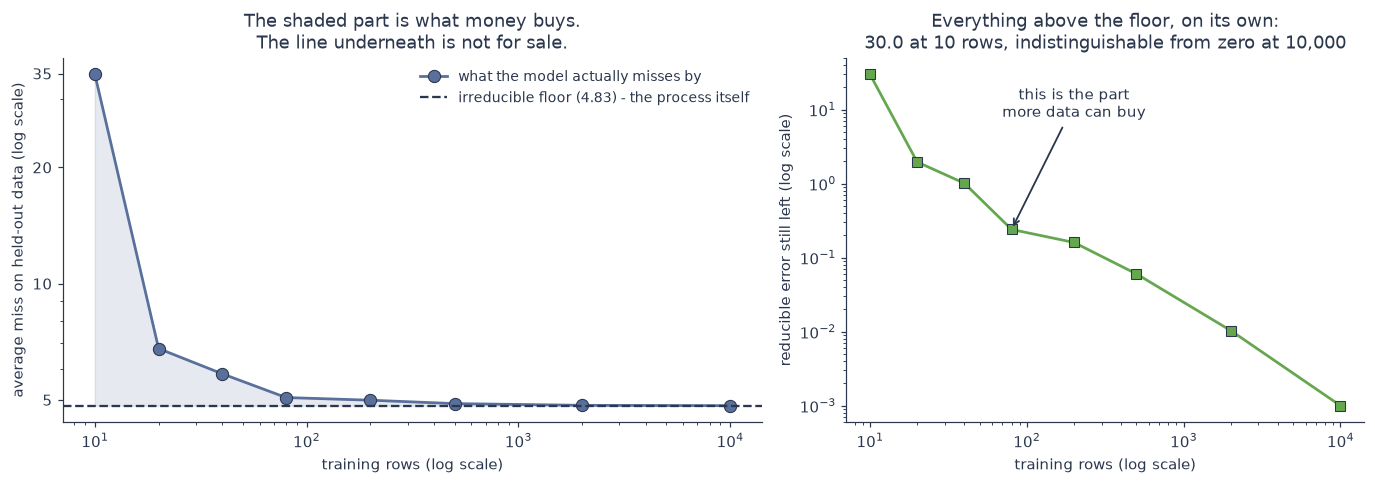

[PASS] Reducible part at 10 rows: 30.03. At 10,000 rows: 0.00.


In [12]:
# --- Figure: the curve that flattens, and the floor it flattens onto.
# --- Both axes are log: the error spans an order of magnitude, and on a linear axis the n=10 point
# --- crushes the interesting region into a strip (the LL-10 lesson, applied).
fig, (ax, ax_gap) = plt.subplots(1, 2, figsize=(12.6, 4.5), gridspec_kw={"width_ratios": [1.35, 1]})

sizes = [r["training rows"] for r in rows]
maes = [r["average miss"] for r in rows]
# Clamped at 0.001 only so the last point can be drawn on a log axis - the measured value there is
# 0.00 (the fit is as good as the true rule, to two decimals).
reducible = [max(m - IRREDUCIBLE, 1e-3) for m in maes]

ax.plot(sizes, maes, marker="o", markersize=8, linewidth=1.8, color=VSP["navy"],
        markeredgecolor=VSP["ink"], markeredgewidth=0.7, label="what the model actually misses by")
ax.axhline(IRREDUCIBLE, color=VSP["ink"], linestyle="--", linewidth=1.5,
           label=f"irreducible floor ({IRREDUCIBLE:.2f}) - the process itself")
ax.fill_between(sizes, IRREDUCIBLE, maes, color=VSP["navy"], alpha=0.15)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("training rows (log scale)")
ax.set_ylabel("average miss on held-out data (log scale)")
ax.set_title("The shaded part is what money buys.\nThe line underneath is not for sale.", fontsize=11.5)
ax.set_yticks([5, 10, 20, 35])
ax.get_yaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.get_yaxis().set_minor_formatter(plt.matplotlib.ticker.NullFormatter())
ax.legend(loc="upper right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Right panel: the reducible part alone, which is the quantity a client is actually buying.
ax_gap.plot(sizes, reducible, marker="s", markersize=7, linewidth=1.8, color=VSP["green"],
            markeredgecolor=VSP["ink"], markeredgewidth=0.7)
ax_gap.set_xscale("log")
ax_gap.set_yscale("log")
ax_gap.set_xlabel("training rows (log scale)")
ax_gap.set_ylabel("reducible error still left (log scale)")
ax_gap.set_title("Everything above the floor, on its own:\n"
                 f"{reducible[0]:.1f} at 10 rows, indistinguishable from zero at 10,000",
                 fontsize=11.5)
ax_gap.spines[["top", "right"]].set_visible(False)
ax_gap.annotate("this is the part\nmore data can buy", xy=(80, reducible[3]), xytext=(200, 8.0),
                fontsize=9.5, color=VSP["ink"], ha="center",
                arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.2))

fig.tight_layout()
plt.show()

assert maes[0] > 5 * IRREDUCIBLE, "the small-n end should be dramatically worse than the floor"
assert abs(maes[-1] - IRREDUCIBLE) < 0.05, "the large-n end should sit on the floor"
print(f"[PASS] Reducible part at 10 rows: {maes[0] - IRREDUCIBLE:.2f}. "
      f"At 10,000 rows: {maes[-1] - IRREDUCIBLE:.2f}.")

### Why this is the sentence clients remember

You have just priced the honest version of *"how much data do we need?"* — the question `LSN-1.6` is built
around, and the one every vendor answers with **"more data always helps."** It does not. It helps
enormously, then it stops, and the stopping point is a property of the client's own process rather than of
your model.

Two things to carry:

- **In `LSN-1.4` you will train a real model on 10, 100, 1,000 and 10,000 handwritten digits and watch this
  exact curve appear.** It flattens for this reason. You are meeting the shape three weeks early.
- **The client sentence:** *"More data will move about this much of your error. This much of it is
  variation in your own process, and no model removes that — so let's design around it instead of paying
  to chase it."*

That is a different conversation from "yes, send more data," and it is the one that gets believed.

---

# Segment 2 — Why this matters commercially *(20 min)*

## The support ticket

VSP runs a **meeting-RAG** system in production — transcripts in, questions answered with citations. It is
the one VSP system where clients meet output variation face to face, and *"is that a bug or a property?"* is
a live support question. The system is walked end to end in `LSN-3.6`; today it is one ticket.

> **SUP-2291 · Priority: P2 · Reported by: client-side product owner**
>
> *"Asked the assistant what we committed to on the Meridian integration. Got one answer this morning and a
> differently-worded answer this afternoon — same question, same account. If it can't answer consistently we
> can't put it in front of our own customers. Please advise."*

**Work it as a group, in this order — ten minutes, no slides:**

1. **Is it a defect?** Look at the two answers printed in the segment-1 sampler cell. Both cite the same
   meeting at the same timestamp. Both say read-only sync, end of Q2, agreed March 14. **The facts are
   identical; the sentence is not.** By the sampler's own arithmetic that happens **71.8%** of the time at
   temperature 1.
2. **What did we promise?** Nobody wrote *"answers will be worded identically"* — and nobody wrote that they
   won't. **Silence is a promise**, and the client filled it in with the only model they had: a database
   query. That is the actual defect, and it is ours.
3. **What should we have promised?** The three questions in the next two tables, answered *before* the demo.

### Bug or property — the triage you can run in front of a client

| What the user saw | Verdict | Why |
|---|---|---|
| Different **wording**, same facts, same citation | **Property** | Sampling. Expected, measurable, and tunable with temperature. |
| Different **facts** between two runs ("Q2" vs "Q3") | **Bug, and a serious one** | Sampling changes phrasing. If it changes *content*, retrieval is unstable or the context is too thin. Escalate. |
| An answer with **no citation**, or a citation that does not resolve | **Bug** | A pinnable contract: no citation, no answer. Nothing stochastic about it. |
| An answer drawn from a meeting this user **may not read** | **Bug — sev 1** | Permission filtering belongs at retrieval time (`LSN-3.6`), not in the prompt. Never a property. |
| Same question, **materially different quality** morning vs afternoon | **Investigate** | Could be retrieval drift, an index rebuild, or a silent model-version change upstream. |

Row 1 is the one to get right today, because getting it wrong in either direction is expensive: call a real
content bug "just sampling" and you ship something unreliable; call sampling a bug and you burn a sprint
chasing a property.

## What you pin, and what you cannot promise

*"It varies"* is not something a client can buy. **"It varies in these ways, within these bounds, and here
is what is nailed down"** is.

| Pin it | How | What it buys the client |
|---|---|---|
| **Temperature** | Set it explicitly — often 0 or near 0 for factual retrieval. Never leave it at a default. | The narrowest variation the task allows, and a written number in the SOW. |
| **Model version** | A dated snapshot, not a floating alias. Upgrades become a scheduled change with a re-run of the eval set. | No silent behaviour change on a Tuesday because a provider shipped. |
| **Prompt + template version** | Version-controlled, deployed like code, id stamped on every logged answer. | Any answer can be reproduced and diffed. |
| **Retrieval config** | Index snapshot id, chunking, top-k, filters. | Yesterday's answer can be explained rather than apologised for. |
| **Seeds, where the API exposes them** | Log the seed next to the request id. | A support ticket becomes a replay instead of a mystery. |
| **The eval set** | A golden question set, versioned, with a threshold. | The thing you are actually contracting on — priced in the cell below. |

| Cannot promise | Say this instead |
|---|---|
| Byte-identical wording between two runs | "Identical **facts and citations**; wording may vary — here is the measured rate." |
| Identical answers after a model upgrade | "Upgrades are scheduled, and we re-run the eval set before and after. You see both numbers." |
| Identical answers after re-indexing | "New content changes answers — that is the product working. Content changes are logged." |
| 100% correctness | "≥ *N*% on a versioned golden set, and every answer carries a citation the user can check." |

**Acceptance criteria for a probabilistic system are eval sets and thresholds — never exact-match outputs.**
The lesson plan's example is *"≥ 90% of a 50-question test set judged correct."* Good sentence. Now do the
arithmetic on it, because a threshold measured on a small sample is itself stochastic.

In [13]:
# --- Segment 2: what an acceptance criterion actually costs. The lesson plan's criterion, priced.
GOLDEN_QUESTIONS = 50        # "a 50-question test set"
PASS_BAR = 0.90              # ">= 90% judged correct"
TRUE_QUALITY = 0.92          # the system is genuinely BETTER than the bar it has to clear
need = int(np.ceil(PASS_BAR * GOLDEN_QUESTIONS))
print(f"Criterion: >= {100 * PASS_BAR:.0f}% of {GOLDEN_QUESTIONS} questions "
      f"-> at least {need} of {GOLDEN_QUESTIONS} judged correct.")
print(f"The system under test is genuinely {100 * TRUE_QUALITY:.0f}% good. It should pass. Watch.\n")

# Eight acceptance runs of the same suite against the same system. Same seed trick: one parent,
# eight children. Each question is answered correctly with probability 0.92, independently -
# a simplification, priced honestly at the bottom of this cell.
suite_seeds = np.random.SeedSequence(50).spawn(8)
results = [int(np.random.default_rng(s).binomial(GOLDEN_QUESTIONS, TRUE_QUALITY)) for s in suite_seeds]
display(pd.DataFrame({
    "acceptance run": [f"#{i}" for i in range(1, 9)],
    "correct / 50": results,
    "measured": [f"{100 * c / GOLDEN_QUESTIONS:.0f}%" for c in results],
    "verdict": ["PASS" if c >= need else "FAIL - meeting with the client" for c in results],
}).set_index("acceptance run"))


def binom_cdf(k, n, p):
    """P(X <= k) for X ~ Binomial(n, p). Exact, stdlib only."""
    return sum(comb(n, i) * p ** i * (1 - p) ** (n - i) for i in range(k + 1))


p_fail_50 = binom_cdf(need - 1, GOLDEN_QUESTIONS, TRUE_QUALITY)
sim = np.random.default_rng(9001).binomial(GOLDEN_QUESTIONS, TRUE_QUALITY, 400_000)
print(f"\nP(a genuinely 92%-good system FAILS a 90% bar on 50 questions)")
print(f"   exact                     : {100 * p_fail_50:.1f}%")
print(f"   400,000 simulated runs    : {100 * (sim < need).mean():.1f}%")
print(f"   observed in the 8 runs above: {sum(1 for c in results if c < need)} of 8 failed.")
print("One run in five, forever, on a system that is better than the bar it is being held to.\n")

# The 95% central range of the measured score, exactly.
_c, lo, hi = 0.0, None, None
for k in range(GOLDEN_QUESTIONS + 1):
    _c += comb(GOLDEN_QUESTIONS, k) * TRUE_QUALITY ** k * (1 - TRUE_QUALITY) ** (GOLDEN_QUESTIONS - k)
    if lo is None and _c >= 0.025:
        lo = k
    if hi is None and _c >= 0.975:
        hi = k
print(f"On 50 questions a 92%-good system measures anywhere in "
      f"{100 * lo / GOLDEN_QUESTIONS:.0f}% - {100 * hi / GOLDEN_QUESTIONS:.0f}% "
      f"(95% of the time).\nThat entire range is the same system.\n")

display(pd.DataFrame([{"golden questions": n,
                       "need correct": int(np.ceil(PASS_BAR * n)),
                       "P(fail) if truly 92% good":
                           f"{100 * binom_cdf(int(np.ceil(PASS_BAR * n)) - 1, n, 0.92):.1f}%",
                       "P(fail) if truly 95% good":
                           f"{100 * binom_cdf(int(np.ceil(PASS_BAR * n)) - 1, n, 0.95):.1f}%"}
                      for n in (50, 100, 200, 500, 1_000)]).set_index("golden questions"))

print("Two honest ways out, and you pick one BEFORE signing:")
print("  1. Grow the eval set - 470 questions is where a 92% system clears a 90% bar 95% of the time.")
print(f"  2. Keep a margin - at 95% true quality even 50 questions fails only "
      f"{100 * binom_cdf(need - 1, GOLDEN_QUESTIONS, 0.95):.1f}% of the time.")
print("  Best: both, plus 'measured on the versioned golden set v1.3, re-run every release' in the SOW.\n")

# The independence simplification, priced rather than hidden (the LSN-0.2 discipline).
print("[HONEST] A real golden set is not 50 coin flips: most questions are always right or always")
print("         wrong, and a handful sit on the edge. Take 40 always-right + 10 borderline at 60%")
print(f"         (the same 92% average): P(fail) = {100 * binom_cdf(4, 10, 0.60):.1f}% instead of "
      f"{100 * p_fail_50:.1f}%. Smaller, never zero -")
print("         and the borderline questions are exactly the ones a client picks for the demo.")

Criterion: >= 90% of 50 questions -> at least 45 of 50 judged correct.
The system under test is genuinely 92% good. It should pass. Watch.



,correct / 50,measured,verdict
acceptance run,,,
#1,46,92%,PASS
#2,48,96%,PASS
#3,42,84%,FAIL - meeting with the client
#4,49,98%,PASS
#5,44,88%,FAIL - meeting with the client
#6,47,94%,PASS
#7,47,94%,PASS
#8,46,92%,PASS



P(a genuinely 92%-good system FAILS a 90% bar on 50 questions)
   exact                     : 20.8%
   400,000 simulated runs    : 20.7%
   observed in the 8 runs above: 2 of 8 failed.
One run in five, forever, on a system that is better than the bar it is being held to.

On 50 questions a 92%-good system measures anywhere in 84% - 98% (95% of the time).
That entire range is the same system.



,need correct,P(fail) if truly 92% good,P(fail) if truly 95% good
golden questions,,,
50,45,20.8%,3.8%
100,90,17.6%,1.1%
200,180,12.2%,0.1%
500,450,4.5%,0.0%
1000,900,1.0%,0.0%


Two honest ways out, and you pick one BEFORE signing:
  1. Grow the eval set - 470 questions is where a 92% system clears a 90% bar 95% of the time.
  2. Keep a margin - at 95% true quality even 50 questions fails only 3.8% of the time.
  Best: both, plus 'measured on the versioned golden set v1.3, re-run every release' in the SOW.

[HONEST] A real golden set is not 50 coin flips: most questions are always right or always
         wrong, and a handful sit on the edge. Take 40 always-right + 10 borderline at 60%
         (the same 92% average): P(fail) = 16.6% instead of 20.8%. Smaller, never zero -
         and the borderline questions are exactly the ones a client picks for the demo.


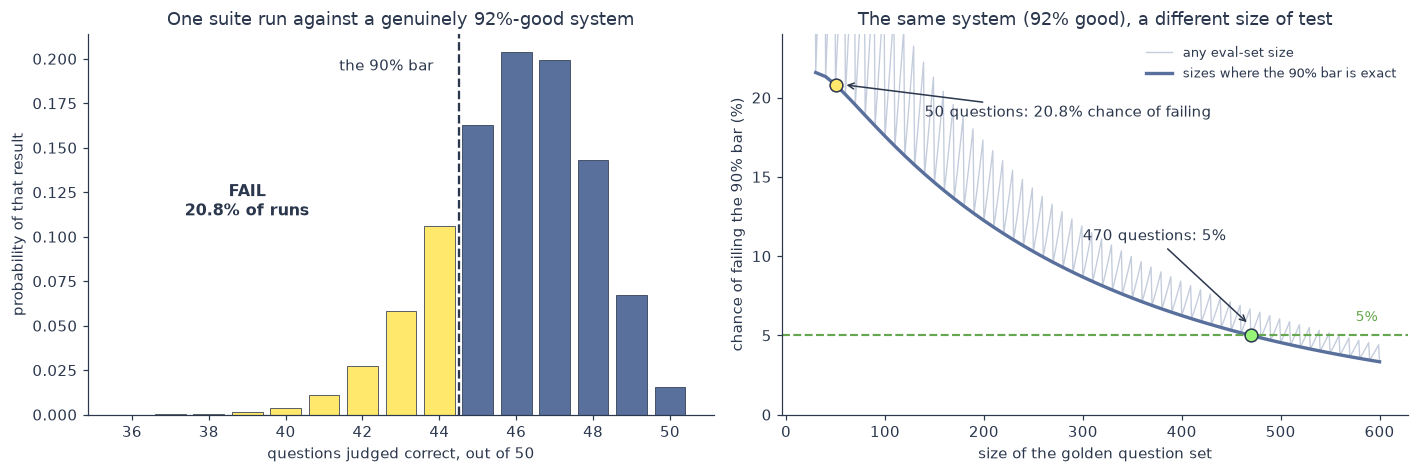

The faint sawtooth on the right is not drawing noise: '90% of 47 questions' rounds up to 43, so
the real bar moves in whole answers and some sizes are quietly stricter than their neighbours.
Pick a size where 90% is a whole number of questions - the bold line - and one thing fewer is
negotiable at signing time.


In [14]:
# --- Figure: an acceptance threshold on a small eval set is itself a coin toss.
fig, (ax_pmf, ax_n) = plt.subplots(1, 2, figsize=(13.0, 4.4))

ks = np.arange(36, GOLDEN_QUESTIONS + 1)
pmf = np.array([comb(GOLDEN_QUESTIONS, int(k)) * TRUE_QUALITY ** int(k)
                * (1 - TRUE_QUALITY) ** (GOLDEN_QUESTIONS - int(k)) for k in ks])
ax_pmf.bar(ks, pmf, color=[VSP["yellow"] if k < need else VSP["navy"] for k in ks],
           edgecolor=VSP["ink"], linewidth=0.5)
ax_pmf.axvline(need - 0.5, color=VSP["ink"], linestyle="--", linewidth=1.5)
ax_pmf.text(need - 0.9, pmf.max() * 0.95, "the 90% bar  ", ha="right", fontsize=9.5, color=VSP["ink"])
ax_pmf.text(39.0, pmf.max() * 0.55, f"FAIL\n{100 * p_fail_50:.1f}% of runs", ha="center", fontsize=10.5,
            fontweight="bold", color=VSP["ink"])
ax_pmf.set_xlabel("questions judged correct, out of 50")
ax_pmf.set_ylabel("probability of that result")
ax_pmf.set_title("One suite run against a genuinely 92%-good system")
ax_pmf.spines[["top", "right"]].set_visible(False)

# Every size from 25 to 600 (thin): the bar lands on a whole question, so the curve is a sawtooth.
every_n = np.arange(25, 601)
ax_n.plot(every_n, [100 * binom_cdf(int(np.ceil(PASS_BAR * n)) - 1, int(n), TRUE_QUALITY)
                    for n in every_n], color=VSP["navy"], alpha=0.35, linewidth=0.9,
          label="any eval-set size")
# Sizes where 90% is a whole number of questions (multiples of 10): the ones worth choosing.
clean_n = np.arange(30, 601, 10)
ax_n.plot(clean_n, [100 * binom_cdf(int(round(PASS_BAR * n)) - 1, int(n), TRUE_QUALITY)
                    for n in clean_n], color=VSP["navy"], linewidth=2.2,
          label="sizes where the 90% bar is exact")
ax_n.axhline(5, color=VSP["green"], linestyle="--", linewidth=1.4)
ax_n.text(598, 5.9, "5%", ha="right", fontsize=9, color=VSP["green"])
ax_n.scatter([50], [100 * p_fail_50], s=70, color=VSP["yellow"], edgecolor=VSP["ink"], zorder=3)
ax_n.annotate(f"50 questions: {100 * p_fail_50:.1f}% chance of failing",
              xy=(58, 100 * p_fail_50), xytext=(140, 18.8), fontsize=9.5, color=VSP["ink"],
              arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.0))
ax_n.scatter([470], [5.0], s=70, color=VSP["mint"], edgecolor=VSP["ink"], zorder=3)
ax_n.annotate("470 questions: 5%", xy=(468, 5.7), xytext=(300, 11.0), fontsize=9.5, color=VSP["ink"],
              arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.0))
ax_n.legend(fontsize=8.5, loc="upper right")
ax_n.set_xlabel("size of the golden question set")
ax_n.set_ylabel("chance of failing the 90% bar (%)")
ax_n.set_title("The same system (92% good), a different size of test")
ax_n.set_ylim(0, 24)
ax_n.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("The faint sawtooth on the right is not drawing noise: '90% of 47 questions' rounds up to 43, so")
print("the real bar moves in whole answers and some sizes are quietly stricter than their neighbours.")
print("Pick a size where 90% is a whole number of questions - the bold line - and one thing fewer is")
print("negotiable at signing time.")

## "All models are wrong, some are useful" — as a working attitude

George Box's line usually gets deployed as a shrug. It is the opposite of a shrug. Unpacked, it is a job
description:

- **All models are wrong** — every one of them, including the ones in production, including the deterministic
  ones. A model is a compression of reality; its error is not a bug to be closed, it is a **quantity to be
  measured**.
- **Some are useful** — usefulness is not "no errors". It is: the errors are **understood** (you know which
  kind), **bounded** (you know how big, and how often), and **priced in** (the workflow survives them, and
  somebody has decided who eats the cost).

So the deliverable is never *"a system that is right"*. It is **a system whose errors are understood,
bounded, and priced in** — which is exactly why the pin list and the eval set above are commercial artifacts,
not engineering hygiene.

Three sentences that do this work in a room, in order:

1. *"It's a sampling system, so wording varies between runs — the facts and the citations won't. Here's the
   measured rate."*
2. *"We pin temperature, model version, prompt version and the index snapshot, and we log the request id, so
   any answer you don't like can be replayed."*
3. *"We're not contracting on exact answers, we're contracting on a number: ≥ 90% correct on a versioned
   golden set, re-run every release. Let's build that set together — with your questions in it."*

That third sentence is the sale. A client's own questions inside the eval set is the moment a probabilistic
system stops being a leap of faith. Write it down before the demo, not after the ticket.

In [15]:
# --- Segment 2 rehearsal (5 min, in pairs). Say it in writing once, before you have to say it live.
#     This cell never crashes; it tells you what still needs work. Nothing here is graded.

# One or two sentences, in your own words, to the client on SUP-2291. Answer the ticket AND set the
# expectation for the next twelve months. The words "bug" and "just" are off the table.
CLIENT_SENTENCE = ""

# One acceptance criterion you would actually sign for a probabilistic feature.
# It needs a number, a named set to measure on, and a cadence.
ACCEPTANCE_CRITERION = ""

# ---------------------------------------------------------------- checker (do not edit below)
_todo = []
if len(CLIENT_SENTENCE.strip()) < 80:
    _todo.append("CLIENT_SENTENCE: 80+ characters. Two things have to be in it - what varies, and what "
                 "does not. If you cannot write it calmly here, you will not say it calmly on a call.")
if len(ACCEPTANCE_CRITERION.strip()) < 40:
    _todo.append("ACCEPTANCE_CRITERION: 40+ characters, and testable by somebody who dislikes you. "
                 "A number, a named set, a cadence.")

_flags = []
_over = [w for w in ("guarantee", "identical", "always the same", "never varies", "deterministic",
                     "100%", "exactly the same") if w in CLIENT_SENTENCE.lower()]
if _over:
    _flags.append(f"you used {', '.join(repr(w) for w in _over)} - re-read the sentence as a lawyer "
                  f"would. Promising sameness is the mistake that created SUP-2291.")
if "just" in CLIENT_SENTENCE.lower() or "bug" in CLIENT_SENTENCE.lower():
    _flags.append("'just' and 'bug' were both off the table: one dismisses the client, the other "
                  "concedes a defect that does not exist. Rewrite around what is pinned.")
if not any(ch.isdigit() for ch in ACCEPTANCE_CRITERION):
    _flags.append("ACCEPTANCE_CRITERION has no number in it. A criterion without a number is a hope.")
_set_words = ("eval", "golden", "test set", "question set", "suite", "benchmark", "regression set")
if len(ACCEPTANCE_CRITERION.strip()) >= 40 and not any(w in ACCEPTANCE_CRITERION.lower() for w in _set_words):
    _flags.append("name the SET the number is measured on: '90% correct' measured on what, judged by whom?")

if _todo:
    for _t in _todo:
        print(f"[TODO] {_t}")
    print("\n       Five minutes, in pairs: one plays the product owner from SUP-2291, one answers.")
    print("       Then swap. A pair that finishes early takes the follow-up: 'so can you turn the")
    print("       randomness off?' (Mostly yes - temperature 0 - then re-read the misfile table.)")
else:
    out_dir = REPO_ROOT / "outputs" / "lsn-0.4"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"client_line_{getpass.getuser()}.json"
    out_path.write_text(json.dumps({
        "lesson": "LSN-0.4", "serves": ["OUT-0.2"], "segment": "2 - commercial expectations",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "ticket": "SUP-2291 (meeting-RAG: same question, differently-worded answers)",
        "client_sentence": CLIENT_SENTENCE.strip(),
        "acceptance_criterion": ACCEPTANCE_CRITERION.strip(),
    }, indent=2))
    print("[PASS] You have a sentence and a criterion on file.")
    print(f"[SAVED] {out_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    if _flags:
        print("\n       [advisory only - the save is done] read these before you use it on a client:")
        for _f in _flags:
            print(f"        - {_f}")
    else:
        print("       No flags. Read it out loud to your pair anyway - it has to survive being said.")

[TODO] CLIENT_SENTENCE: 80+ characters. Two things have to be in it - what varies, and what does not. If you cannot write it calmly here, you will not say it calmly on a call.
[TODO] ACCEPTANCE_CRITERION: 40+ characters, and testable by somebody who dislikes you. A number, a named set, a cadence.

       Five minutes, in pairs: one plays the product owner from SUP-2291, one answers.
       Then swap. A pair that finishes early takes the follow-up: 'so can you turn the
       randomness off?' (Mostly yes - temperature 0 - then re-read the misfile table.)


---

# Segment 3 — Bridge to `MOD-1` *(15 min)*

*No new theory in this segment. It is a map of where today's three words get used for the rest of the
program, plus the `ASM-0` reminder.*

`MOD-1` opens with `LSN-1.1`: every client "AI" ask is one of **five ML jobs** — or it is not ML at all. Here
is the part that belongs to today: **all five return a probabilistic answer.** Different shapes of answer,
different forms of confidence, same bucket.

| The job (`LSN-1.1`) | The client's ask | What comes out | The confidence that comes with it | Where you learn it |
|---|---|---|---|---|
| **Classify** — sort it | "route these 800 tickets to the right team" | a label per item | a probability **per class**; the label is just the biggest of them | read: `LSN-1.2` · grade: `LSN-1.3` |
| **Cluster** — group it | "group our 40,000 customers into segments" | a group id per item | a fit or a distance, **not** a probability — and the id means nothing until a human names it | read: `LSN-1.2` |
| **Regress** — guess a number | "forecast next quarter's cloud spend" | a number, **with units** | a typical miss (MAE) and a spread — an error bar, not a decimal place | grade: `LSN-1.3` |
| **Propensity** — give the odds | "the odds this shipment arrives late" | a probability, per entity | the number **is** the answer, so calibration is the whole game | read: `LSN-1.2` · grade: `LSN-1.3` |
| **Recommend** — pick the next move | "which spare parts to load on the truck" | a **ranked** list | a relative score: rank 1 beats rank 2, and neither is a percentage | read: `LSN-1.2` |
| *(not ML)* **Generate** — write / converse | "a chatbot over our 500-page manual" | text, ideally with citations | usually **no confidence reported at all** — which is why you pin temperature and measure on an eval set | `MOD-2`: `LSN-2.1`, `LSN-2.4` |

Read that last row against the five above it. The reason `MOD-2` needs its own module is not that the models
are bigger. It is that the output arrives **with no confidence attached**, so you have to manufacture the
number yourself — with the golden set from segment 2.

**And the three buckets apply to every row:** the output is **probabilistic**; inference is **deterministic**
once the weights are pinned; the training that produced those weights was **stochastic**, so next month's
retrain is a slightly different model — the eight-retrain fan from segment 1. `LSN-1.2` teaches you to read
these outputs and `LSN-1.3` to grade them, and `LSN-1.3` reopens **`LSN-0.3`'s fraud detector** with a formal
report card, so keep that counts table.

---

# Homework — 100 min (runs across the weekend)

The 2026-08-03 rescope gave every lesson a 2 h out-of-session budget, so *"no homework, it's checkpoint
week"* no longer holds. This is where the module consolidates and where `ASM-0` actually lives.

| # | Task | Time |
|---|---|---|
| 1 | `ASM-0` prep — the week's four misconceptions, in your own words | 25 min |
| 2 | The three-bucket sort, applied to a system you actually work on | 25 min |
| 3 | Two halves of one acceptance criterion: **how many questions**, and **is the confidence honest** | 20 min |
| 4 | `ASM-0` itself — async quiz, ~20 questions, pass bar 80% | 30 min |

Tasks 1–3 are self-checking below. Nothing here gates your save; the checkers tell you what still needs
work.

In [16]:
# --- HOMEWORK TASK 1 (25 min). The week killed four misconceptions. Write each one down in your own
# --- words - not the notebook's. If you cannot say it plainly here, you cannot say it to a client.
MISCONCEPTION_0_2 = ""   # LSN-0.2: what does a single number hide?
MISCONCEPTION_0_3 = ""   # LSN-0.3: what did "99% accurate" turn out not to mean?
CAUSATION         = ""   # LSN-0.3: A moves with B. What are the four explanations?
VARIATION         = ""   # LSN-0.4: two runs disagree. Why is that not automatically a defect?

# ---------------------------------------------------------------- checker (do not edit below)
_answers = {"MISCONCEPTION_0_2": MISCONCEPTION_0_2, "MISCONCEPTION_0_3": MISCONCEPTION_0_3,
            "CAUSATION": CAUSATION, "VARIATION": VARIATION}
_short = [k for k, v in _answers.items() if len(v.strip()) < 60]
if _short:
    print("[TODO] 60+ characters each, in your own words:")
    for k in _short:
        print(f"        - {k}")
else:
    print(f"[PASS] Four misconceptions written, {sum(len(v.split()) for v in _answers.values())} words total.")
    if "four" not in CAUSATION.lower() and "4" not in CAUSATION:
        print("[NOTE] CAUSATION: the useful version names how many explanations there are, then lists them.")

[TODO] 60+ characters each, in your own words:
        - MISCONCEPTION_0_2
        - MISCONCEPTION_0_3
        - CAUSATION
        - VARIATION


In [17]:
# --- HOMEWORK TASK 2 (25 min). Pick a system you actually work on. List five behaviours, sort each,
# --- and for every non-deterministic one write the acceptance criterion you would sign.
SYSTEM_NAME = ""

# (behaviour, bucket, acceptance criterion). Bucket: "deterministic" / "probabilistic" / "stochastic".
# Deterministic rows may leave the criterion empty - that is the point of sorting first.
BEHAVIOURS = [
    # ("nightly invoice totals recompute", "deterministic", ""),
    # ("late-delivery risk score per shipment", "probabilistic", "..."),
]

# ---------------------------------------------------------------- checker (do not edit below)
_VALID = {"deterministic", "probabilistic", "stochastic"}
_issues = []
if len(SYSTEM_NAME.strip()) < 3:
    _issues.append("SYSTEM_NAME is empty - name the real system, not a placeholder.")
if len(BEHAVIOURS) < 5:
    _issues.append(f"BEHAVIOURS has {len(BEHAVIOURS)} rows, needs 5.")
for _i, _row in enumerate(BEHAVIOURS):
    if len(_row) != 3:
        _issues.append(f"row {_i}: expected (behaviour, bucket, criterion).")
        continue
    _b, _bucket, _crit = _row
    if _bucket not in _VALID:
        _issues.append(f"row {_i}: bucket {_bucket!r} is not one of {sorted(_VALID)}.")
    elif _bucket != "deterministic":
        if len(_crit.strip()) < 40:
            _issues.append(f"row {_i} ({_b[:34]}): non-deterministic rows need a criterion of 40+ chars.")
        elif not any(_c.isdigit() for _c in _crit):
            _issues.append(f"row {_i} ({_b[:34]}): a criterion without a number is a wish. "
                           f"Add a threshold and the set you measure it on.")
if _issues:
    print("[TODO]")
    for _msg in _issues:
        print(f"        - {_msg}")
else:
    _nd = sum(1 for _, _bk, _ in BEHAVIOURS if _bk != "deterministic")
    print(f"[PASS] {SYSTEM_NAME}: {len(BEHAVIOURS)} behaviours sorted, "
          f"{_nd} non-deterministic, each with a numeric criterion.")

[TODO]
        - SYSTEM_NAME is empty - name the real system, not a placeholder.
        - BEHAVIOURS has 0 rows, needs 5.


### Task 3 — two halves of one acceptance criterion *(20 min)*

An acceptance criterion for a probabilistic system has two parts, and most people write only the first.

**(a) How many questions does the bar need?** *(12 min — the arithmetic is in segment 2's cell above.)*
A genuinely 92%-good system facing a *"≥ 90% of the test set judged correct"* bar fails **20.8%** of the
time on 50 questions, and needs **470** before that drops below 5%. Re-read that output, then write the
sentence you would say to a client who wants the bar set on 50.

**(b) Is the confidence honest?** *(8 min — the cell below.)* Sizing tells you how many questions to ask.
It says nothing about whether the number the model attaches to each answer means anything. That property
has a name — **calibration** — and it is exactly what segment 1's two scorers differed on: same decisions,
same accuracy, one telling the truth about its certainty and one not.

The check is mechanical: bucket predictions by the confidence they stated, and compare each bucket's
stated confidence to the share that were actually right.

In [18]:
# --- HOMEWORK TASK 3b (8 min). A vendor hands you 4,000 predictions with a confidence on each.
# --- Bucket them and find out whether the confidence is worth anything.
_hw = np.random.default_rng(519)
_N_HW = 4_000
_true_p = _hw.beta(2.2, 2.2, _N_HW)                       # each item's real chance of being positive
LABEL = _hw.random(_N_HW) < _true_p                        # what actually happened
PREDICTION = _true_p >= 0.5                                # the call the vendor's model made
_honest = np.maximum(_true_p, 1 - _true_p)                 # the confidence it SHOULD report
_o = np.clip(_honest, 1e-9, 1 - 1e-9)
STATED_CONFIDENCE = 1 / (1 + np.exp(-2.2 * np.log(_o / (1 - _o))))   # what it actually reports
CORRECT = PREDICTION == LABEL

print(f"Predictions: {_N_HW:,}   overall accuracy: {CORRECT.mean():.1%}   "
      f"average confidence claimed: {STATED_CONFIDENCE.mean():.1%}")
print("The vendor's pitch: \"our model is right about 68% of the time and tells you how sure it is.\"\n")

# --- YOUR TURN. Fill the two lists: for each bucket, the average confidence stated and the share
# --- that were actually correct. One line each - np.mean() over a boolean mask does both.
BUCKET_EDGES = np.arange(0.5, 1.01, 0.1)      # 0.5-0.6, 0.6-0.7, 0.7-0.8, 0.8-0.9, 0.9-1.0
SAID = []          # average STATED_CONFIDENCE inside each bucket
OBSERVED = []      # share of CORRECT inside each bucket

# for lo, hi in zip(BUCKET_EDGES[:-1], BUCKET_EDGES[1:]):
#     mask = (STATED_CONFIDENCE >= lo) & (STATED_CONFIDENCE < hi)
#     SAID.append(...)
#     OBSERVED.append(...)

# ---------------------------------------------------------------- checker (do not edit below)
if len(SAID) != 5 or len(OBSERVED) != 5:
    print("[TODO] Fill SAID and OBSERVED with one value per bucket (5 each). "
          "Uncomment the loop above and complete the two appends.")
else:
    _gaps = [abs(s - o) for s, o in zip(SAID, OBSERVED)]
    _table = pd.DataFrame({"bucket": [f"{lo:.1f}-{lo + 0.1:.1f}" for lo in BUCKET_EDGES[:-1]],
                           "said": [round(s, 3) for s in SAID],
                           "observed": [round(o, 3) for o in OBSERVED],
                           "gap (points)": [round(100 * g, 1) for g in _gaps]})
    print(_table.to_string(index=False))
    print(f"\nLargest gap: {100 * max(_gaps):.1f} points.")
    if max(_gaps) > 0.10:
        print("[PASS] You found it: this model is systematically overconfident. Its accuracy claim was "
              "true and its confidence claim is not - which is the whole of OUT-0.2.")
    else:
        print("[NOTE] Expected a large gap here. Re-check that you bucketed on STATED_CONFIDENCE "
              "and averaged CORRECT (not LABEL) inside each bucket.")

Predictions: 4,000   overall accuracy: 68.3%   average confidence claimed: 79.6%
The vendor's pitch: "our model is right about 68% of the time and tells you how sure it is."

[TODO] Fill SAID and OBSERVED with one value per bucket (5 each). Uncomment the loop above and complete the two appends.


In [19]:
# --- HOMEWORK TASK 3, the deliverable. Both halves, in one criterion a client can check.
SIZING_SENTENCE = ""        # 3a - what you say to the client who wants the bar on 50 questions
CALIBRATION_CRITERION = ""  # 3b - "calibrated within X points across confidence buckets", with X and a cadence

# ---------------------------------------------------------------- checker (do not edit below)
_todo = []
if len(SIZING_SENTENCE.strip()) < 80:
    _todo.append("SIZING_SENTENCE: 80+ chars. It needs the failure rate at 50 questions and a number "
                 "you would accept instead.")
if len(CALIBRATION_CRITERION.strip()) < 50:
    _todo.append("CALIBRATION_CRITERION: 50+ chars, and testable by somebody who dislikes you - "
                 "a tolerance in points, the buckets, and how often it gets re-measured.")
elif not any(_c.isdigit() for _c in CALIBRATION_CRITERION):
    _todo.append("CALIBRATION_CRITERION: no number in it. 'Well calibrated' is not a criterion.")
if _todo:
    print("[TODO]")
    for _msg in _todo:
        print(f"        - {_msg}")
else:
    print("[PASS] Both halves written. Task 3 is the one that turns OUT-0.2 into something a client "
          "can hold you to.")
print("\n[NOTE] These checkers are pre-checks, not graders (SI-29). They measure substance, not "
      "correctness - the real check is ASM-0 and the conversation it rehearses.")

[TODO]
        - SIZING_SENTENCE: 80+ chars. It needs the failure rate at 50 questions and a number you would accept instead.
        - CALIBRATION_CRITERION: 50+ chars, and testable by somebody who dislikes you - a tolerance in points, the buckets, and how often it gets re-measured.

[NOTE] These checkers are pre-checks, not graders (SI-29). They measure substance, not correctness - the real check is ASM-0 and the conversation it rehearses.


### Task 4 — `ASM-0`, the checkpoint *(30 min)*

| `ASM-0` | |
|---|---|
| **Format** | Async quiz, ~20 questions, 30 min |
| **Verifies** | `OUT-0.1` (setup evidence) · `OUT-0.2`–`OUT-0.4` — **scenario questions, not definitions** |
| **Covers** | This lesson, plus `LSN-0.2` (distributions, sampling, variance) and `LSN-0.3` (probability, base rates, causation) |
| **Pass bar** | **80%**, one retake within the week |
| **Gate** | Must pass to start `MOD-1` |
| **Setup evidence** | The screenshot of your executed `notebooks/lessons/LSN-0.1_Orientation_Environment_Setup.ipynb` — checkpoint 5 of that notebook |

"Scenario questions, not definitions" means the quiz will not ask you to *define* stochastic. It hands you a
paragraph — a client complaining that two runs disagree, a vendor quoting a confidence, a chart that moved —
and asks what you would say. Everything you need is in this notebook's outputs and in `LSN-0.2` / `LSN-0.3`.

**Time accounting:** pre-work 20 min + homework 100 min (25 + 25 + 20 + 30) = 2 h out-of-session budget.

---

## Wrap-up

**You can now, on demand:**

- sort any system behaviour into **deterministic / probabilistic / stochastic** — and refuse the yes/no
  question by asking **"which part?"**;
- read *"95% confident"* as the **auditable claim** it is (*of the cases it calls 0.95, about 95 in 100 should
  be right*), and say why two systems with **identical accuracy** can differ completely on whether that claim
  holds;
- explain why the **same question returns a differently-worded answer**, and triage a variation ticket into
  **property** (wording) versus **bug** (facts, citations, permissions);
- name what gets **pinned** — temperature, model version, prompt version, retrieval config, seeds — and what
  **cannot be promised**: byte-identical output, sameness across upgrades or re-indexing, 100% correctness;
- write an acceptance criterion that is an **eval set plus a threshold**, and price the threshold: a genuinely
  92%-good system fails a *"≥ 90% of 50 questions"* bar **20.8%** of the time, and needs **470** questions
  before that drops to 5%;
- use *"all models are wrong, some are useful"* as a working standard — errors **understood, bounded, and
  priced in**.

**Next — `MOD-1`, `LSN-1.1`: the five ML jobs & the nesting doll** (1 h session, 30 min pre-work). Triage any
client "AI" ask into classify / cluster / regress / propensity / recommend — or correctly call it a
generative-AI ask. Pre-work is the ML literacy deck through the five-jobs section plus **one real "AI" ask
from your own project history, and your guess at which job it is**. Today's vocabulary is what makes those
five jobs readable — and `ASM-0` is the gate in between.

> One last frame to carry forward. `LSN-0.2`: *how many, and collected how?* · `LSN-0.3`: *conditional on
> what?* · `LSN-0.4`: **does this thing owe me the same answer twice — and which part of it?**